<a href="https://colab.research.google.com/github/youssefahmed11111/house-price-project/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile

import os

with zipfile.ZipFile("archive.zip", "r") as zip_ref:

    zip_ref.extractall("data")

os.listdir("data")

['house_prices.csv']

In [ ]:
import pandas as pd

df = pd.read_csv("data/house_prices.csv")

print("Shape:", df.shape)

print("\nColumns:")

print(df.columns.tolist())

df.head()

Shape: (187531, 21)

Columns:
['Index', 'Title', 'Description', 'Amount(in rupees)', 'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area', 'Dimensions', 'Plot Area']


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [ ]:
print("Dataset shape:", df.shape)

print("\nData types:")

print(df.dtypes)

print("\nMissing values:")

print(df.isna().sum().sort_values(ascending=False))

Dataset shape: (187531, 21)

Data types:
Index                  int64
Title                 object
Description           object
Amount(in rupees)     object
Price (in rupees)    float64
location              object
Carpet Area           object
Status                object
Floor                 object
Transaction           object
Furnishing            object
facing                object
overlooking           object
Society               object
Bathroom              object
Balcony               object
Car Parking           object
Ownership             object
Super Area            object
Dimensions           float64
Plot Area            float64
dtype: object

Missing values:
Plot Area            187531
Dimensions           187531
Society              109678
Super Area           107685
Car Parking          103357
overlooking           81436
Carpet Area           80673
facing                70233
Ownership             65517
Balcony               48935
Price (in rupees)     17665
Floor      

In [ ]:
df = df.copy()

df = df.drop(columns=["Index", "Title", "Description", "Dimensions", "Plot Area"])

df = df.dropna(subset=["Amount(in rupees)", "location"])

print("New shape:", df.shape)

df.head()

New shape: (187531, 16)


,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area
0,42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN
1,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN
2,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN
3,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN
4,1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN


In [ ]:
def parse_amount(x):

    x = str(x).strip().lower()

    try:

        if "lac" in x:

            return float(x.replace("lac", "").strip()) * 100000

        if "cr" in x:

            return float(x.replace("cr", "").strip()) * 10000000

        return float(x.replace(",", ""))

    except:

        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)

df = df.dropna(subset=["price_clean"])

print("Rows after price cleaning:", len(df))

df[["Amount(in rupees)", "price_clean"]].head(10)

Rows after price cleaning: 177847


,Amount(in rupees),price_clean
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0
5,45 Lac,4500000.0
6,16.5 Lac,1650000.0
7,60 Lac,6000000.0
8,60 Lac,6000000.0
9,1.60 Cr,16000000.0


In [ ]:
def parse_area(x):

    if pd.isna(x):

        return None

    x = str(x).lower().strip()

    try:

        if "sqm" in x:

            return float(x.replace("sqm", "").strip()) * 10.764

        if "sqft" in x:

            return float(x.replace("sqft", "").strip())

        return float(x.replace(",", ""))

    except:

        return None

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)

print("Missing carpet areas:", df["carpet_area_sqft"].isna().sum())

df[["Carpet Area", "carpet_area_sqft"]].head(10)

Missing carpet areas: 80991


,Carpet Area,carpet_area_sqft
0,500 sqft,500.0
1,473 sqft,473.0
2,779 sqft,779.0
3,530 sqft,530.0
4,635 sqft,635.0
5,NaN,NaN
6,550 sqft,550.0
7,NaN,NaN
8,NaN,NaN
9,900 sqft,900.0


In [ ]:
df["floor_num"] = df["Floor"].str.extract(r"(\d+)").astype(float)

df["bathroom"] = pd.to_numeric(df["Bathroom"], errors="coerce")

df["balcony"] = pd.to_numeric(df["Balcony"], errors="coerce")

df["furnishing"] = df["Furnishing"].fillna("Unknown")

df["transaction"] = df["Transaction"].fillna("Unknown")

df["ownership"] = df["Ownership"].fillna("Unknown")

df["facing"] = df["facing"].fillna("Unknown")

df["location_grouped"] = df["location"].fillna("Unknown")

print(df[[

    "price_clean",

    "carpet_area_sqft",

    "floor_num",

    "bathroom",

    "balcony",

    "furnishing",

    "transaction",

    "ownership",

    "facing"

]].head())

print("\nMissing values:")

print(df[[

    "price_clean",

    "carpet_area_sqft",

    "floor_num",

    "bathroom",

    "balcony"

]].isna().sum())

   price_clean  carpet_area_sqft  floor_num  bathroom  balcony  \
0    4200000.0             500.0       10.0       1.0      2.0   
1    9800000.0             473.0        3.0       2.0      NaN   
2   14000000.0             779.0       10.0       2.0      NaN   
3    2500000.0             530.0        1.0       1.0      1.0   
4   16000000.0             635.0       20.0       2.0      NaN   

       furnishing transaction             ownership   facing  
0     Unfurnished      Resale               Unknown  Unknown  
1  Semi-Furnished      Resale              Freehold     East  
2     Unfurnished      Resale              Freehold     East  
3     Unfurnished      Resale               Unknown  Unknown  
4     Unfurnished      Resale  Co-operative Society     West  

Missing values:
price_clean             0
carpet_area_sqft    80991
floor_num            6954
bathroom              789
balcony             47175
dtype: int64


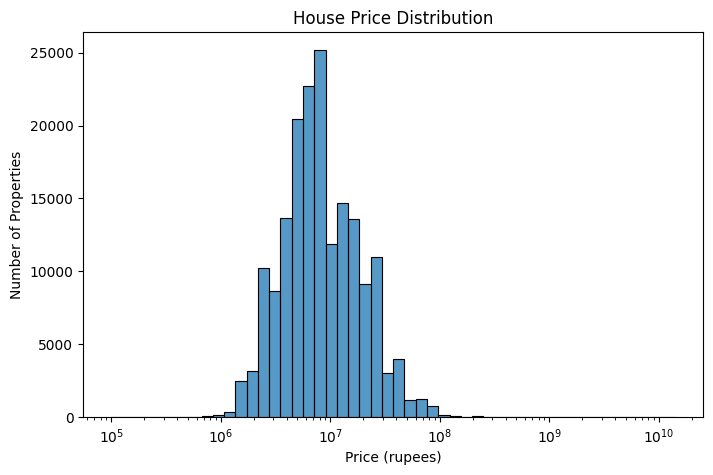

In [ ]:
import matplotlib.pyplot as plt

import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(df["price_clean"], bins=50, log_scale=True)

plt.title("House Price Distribution")

plt.xlabel("Price (rupees)")

plt.ylabel("Number of Properties")

plt.show()

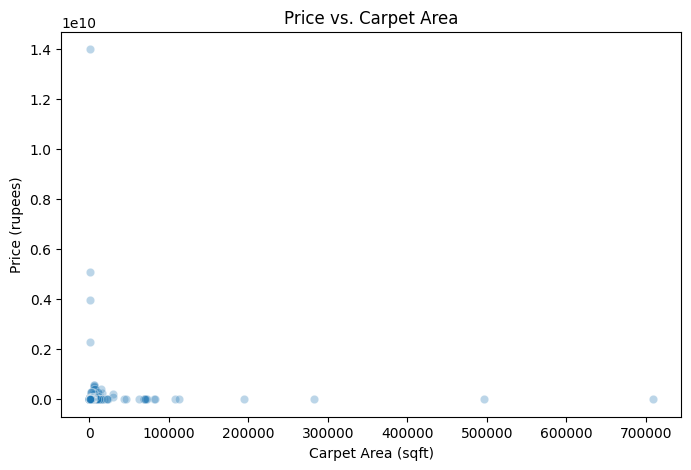

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(

    data=df,

    x="carpet_area_sqft",

    y="price_clean",

    alpha=0.3

)

plt.title("Price vs. Carpet Area")

plt.xlabel("Carpet Area (sqft)")

plt.ylabel("Price (rupees)")

plt.show()

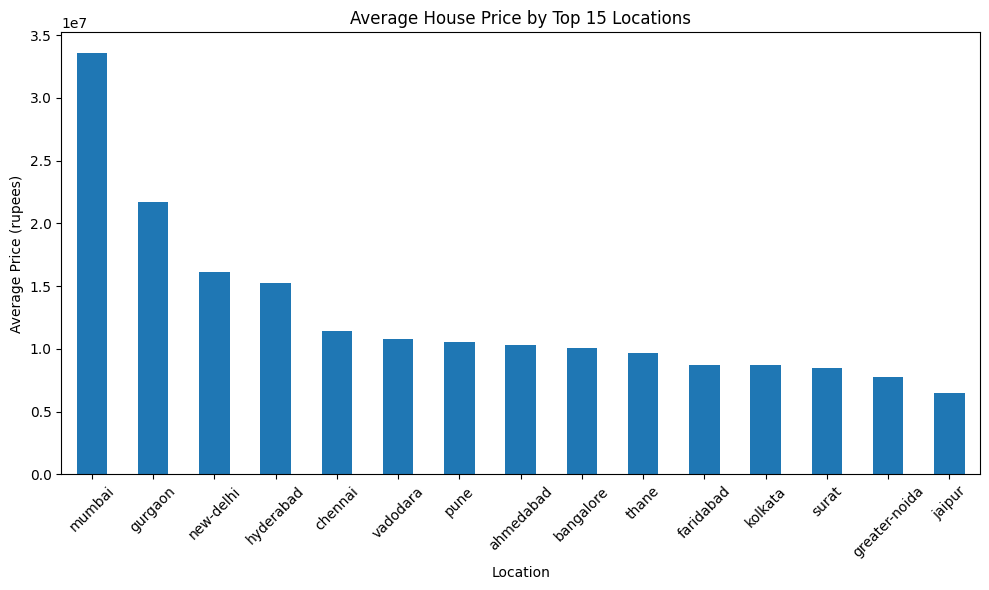

In [ ]:
top_locations = df["location"].value_counts().head(15).index

location_prices = (

    df[df["location"].isin(top_locations)]

    .groupby("location")["price_clean"]

    .mean()

    .sort_values(ascending=False)

)

plt.figure(figsize=(10, 6))

location_prices.plot(kind="bar")

plt.title("Average House Price by Top 15 Locations")

plt.xlabel("Location")

plt.ylabel("Average Price (rupees)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

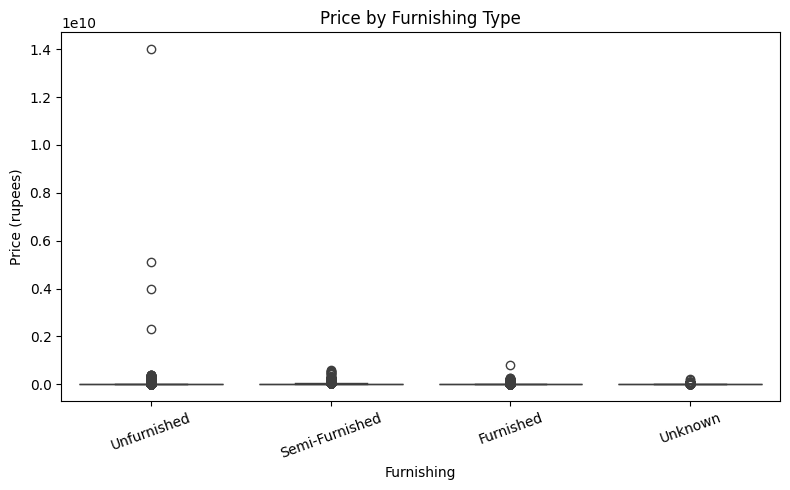

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(

    data=df,

    x="furnishing",

    y="price_clean"

)

plt.title("Price by Furnishing Type")

plt.xlabel("Furnishing")

plt.ylabel("Price (rupees)")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [ ]:
features = [

    "carpet_area_sqft",

    "floor_num",

    "bathroom",

    "balcony",

    "furnishing",

    "transaction",

    "ownership",

    "facing",

    "location_grouped"

]

X = df[features]

y = df["price_clean"]

print("Features:", X.shape)

print("Target:", y.shape)

Features: (177847, 9)
Target: (177847,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X, y, test_size=0.2, random_state=42

)

print("Training data:", X_train.shape)

print("Testing data:", X_test.shape)

Training data: (142277, 9)
Testing data: (35570, 9)


In [ ]:
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor

numeric_features = [

    "carpet_area_sqft",

    "floor_num",

    "bathroom",

    "balcony"

]

categorical_features = [

    "furnishing",

    "transaction",

    "ownership",

    "facing",

    "location_grouped"

]

preprocessor = ColumnTransformer(

    transformers=[

        ("num", SimpleImputer(strategy="median"), numeric_features),

        ("cat", Pipeline([

            ("imputer", SimpleImputer(strategy="most_frequent")),

            ("onehot", OneHotEncoder(handle_unknown="ignore"))

        ]), categorical_features)

    ]

)

model1 = Pipeline([

    ("preprocessor", preprocessor),

    ("model", RandomForestRegressor(

        n_estimators=100,

        random_state=42,

        n_jobs=-1

    ))

])

model1.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np

y_pred1 = model1.predict(X_test)

mae1 = mean_absolute_error(y_test, y_pred1)

rmse1 = np.sqrt(mean_squared_error(y_test, y_pred1))

r2_1 = r2_score(y_test, y_pred1)

print("Random Forest Results")

print("MAE:", mae1)

print("RMSE:", rmse1)

print("R2 Score:", r2_1)

Random Forest Results
MAE: 1848783.2112257842
RMSE: 76322383.51986015
R2 Score: 0.0024355992770965784


In [ ]:
from sklearn.ensemble import RandomForestRegressor

y_train_log = np.log1p(y_train)

model2 = Pipeline([

    ("preprocessor", preprocessor),

    ("model", RandomForestRegressor(

        n_estimators=100,

        random_state=42,

        n_jobs=-1

    ))

])

model2.fit(X_train, y_train_log)

y_pred2_log = model2.predict(X_test)

y_pred2 = np.expm1(y_pred2_log)

mae2 = mean_absolute_error(y_test, y_pred2)

rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))

r2_2 = r2_score(y_test, y_pred2)

print("Log Random Forest Results")

print("MAE:", mae2)

print("RMSE:", rmse2)

print("R2 Score:", r2_2)

Log Random Forest Results
MAE: 1723641.590763265
RMSE: 75393907.53124726
R2 Score: 0.026559080864728024


In [ ]:
results = pd.DataFrame({

    "Model": ["Random Forest", "Log Random Forest"],

    "MAE": [mae1, mae2],

    "RMSE": [rmse1, rmse2],

    "R2 Score": [r2_1, r2_2]

})

results

,Model,MAE,RMSE,R2 Score
0,Random Forest,1.848783e+06,7.632238e+07,0.002436
1,Log Random Forest,1.723642e+06,7.539391e+07,0.026559


In [ ]:
import joblib

joblib.dump(model2, "house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os

print(os.path.exists("house_price_model.pkl"))

print(os.path.getsize("house_price_model.pkl"))

True
383644467
